### Abstract
- 販売数のデータからお弁当の販売数`y`を予測する回帰モデルを作成する。
- データダウンロード先 -> [SIGNATEの練習問題データ](https://user.competition.signate.jp/ja/competition/detail/?competition=b2c7df3442d04e73bdbab95b1dd6f91d&task=4265b59bdd9d4b47af2771fe82dc9b52&tab=dataset)を使用
- 線形と非線形のモデル２つを作成し、これを組み合わせて予測を行う手法を試みる

> RMSE(Root Mean Squared Error)
> - 「平均二乗誤差の平方根」、回帰モデルの制度を測る最もポピュラーな指標の一つ
> - 計算のイメージ
>   1. Error : 予測値と実績値の差を出す。
>   2. Squared : その差を二乗する(マイナスをなくし、大きな差を強調する。)
>   3. Mean : 全データの平均をとる
>   4. Roor : 最後に平方根をとり、単位を元に戻す。
> - メリット
>   - 単位が同じ：結果の単位が「個」や「円」など、元のデータと同じになり、直感的に理解しやすい



|属性          |説明                           |
|--------------|-------------------------------|
|datetime       |インデックスとして使用する日付  |
|y             |販売数                         |
|week          |曜日（月～金）                  |
|soldout       |完売フラグ（0:完売せず、1:完売）|
|name          |メインメニュー                  |
|kcal          |おかずのカロリー（kcal）        |
|remarks       |特記事項                        |
|event         |社内イベント                    |
|payday        |給料日フラグ（1:給料日）        |
|weather       |天気                           |
|precipitation |降水量                         |
|temperature   |気温                           |

In [10]:
# データの読み込みと基本的な情報の確認

import pandas as pd

train = pd.read_csv("./data/01/train.csv")
test = pd.read_csv("./data/01/test.csv")
sample = pd.read_csv("./data/01/sample.csv",header=None) # header=Noneを指定して、1行目をヘッダーとして読み込まないようにする

print("Data Shapes")
print("Train:",train.shape, "Test:",test.shape, "Sample:",sample.shape) # データの行数と列数を表示


train.index = pd.to_datetime(train["datetime"]) # datetimeカラムをインデックスに設定し、時系列データとして扱いやすくする
display(train.head())

print("Train Data Info")
display(train.describe())


print("Train Data Categorical Info")
display(train.describe(include="O")) # include="O"を指定して、オブジェクト型のカラムの基本統計量を表示



Data Shapes
Train: (207, 12) Test: (40, 11) Sample: (40, 2)


,datetime,y,week,soldout,name,kcal,remarks,event,payday,weather,precipitation,temperature
datetime,,,,,,,,,,,,
2013-11-18,2013-11-18,90,月,0,厚切りイカフライ,NaN,NaN,NaN,NaN,快晴,--,19.8
2013-11-19,2013-11-19,101,火,1,手作りヒレカツ,NaN,NaN,NaN,NaN,快晴,--,17.0
2013-11-20,2013-11-20,118,水,0,白身魚唐揚げ野菜あん,NaN,NaN,NaN,NaN,快晴,--,15.5
2013-11-21,2013-11-21,120,木,1,若鶏ピリ辛焼,NaN,NaN,NaN,NaN,快晴,--,15.2
2013-11-22,2013-11-22,130,金,1,ビッグメンチカツ,NaN,NaN,NaN,NaN,快晴,--,16.1


Train Data Info


,y,soldout,kcal,payday,temperature
count,207.000000,207.000000,166.000000,10.0,207.000000
mean,86.623188,0.449275,404.409639,1.0,19.252174
std,32.882448,0.498626,29.884641,0.0,8.611365
min,29.000000,0.000000,315.000000,1.0,1.200000
25%,57.000000,0.000000,386.000000,1.0,11.550000
50%,78.000000,0.000000,408.500000,1.0,19.800000
75%,113.000000,1.000000,426.000000,1.0,26.100000
max,171.000000,1.000000,462.000000,1.0,34.600000


Train Data Categorical Info


,datetime,week,name,remarks,event,weather,precipitation
count,207,207,207,21,14,207,207
unique,207,5,156,6,2,7,8
top,2013-11-18,水,メンチカツ,お楽しみメニュー,ママの会,快晴,--
freq,1,43,6,12,9,53,169


### 欠損値の処理

In [11]:
# 欠損値の確認
import pandas as pd

df = pd.read_csv('./data/01/train.csv') # データを読み込む

print("データの基本情報:")
df.info() # データの基本情報を表示

print("\n欠損値の数:")
print(df.isnull().sum()) # 各列の欠損値の数を表示



データの基本情報:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   datetime       207 non-null    object 
 1   y              207 non-null    int64  
 2   week           207 non-null    object 
 3   soldout        207 non-null    int64  
 4   name           207 non-null    object 
 5   kcal           166 non-null    float64
 6   remarks        21 non-null     object 
 7   event          14 non-null     object 
 8   payday         10 non-null     float64
 9   weather        207 non-null    object 
 10  precipitation  207 non-null    object 
 11  temperature    207 non-null    float64
dtypes: float64(3), int64(2), object(7)
memory usage: 19.5+ KB

欠損値の数:
datetime           0
y                  0
week               0
soldout            0
name               0
kcal              41
remarks          186
event            193
payday           197
weather  

### 欠損値補完と月情報の特徴量の作成

kcalカラムの要約統計量:


count    166.000000
mean     404.409639
std       29.884641
min      315.000000
25%      386.000000
50%      408.500000
75%      426.000000
max      462.000000
Name: kcal, dtype: float64

大きなばらつきがないため、kcalカラムは平均値で補完。

補完後の欠損値の数:


datetime         0
y                0
week             0
soldout          0
name             0
kcal             0
remarks          0
event            0
payday           0
weather          0
precipitation    0
temperature      0
month            0
dtype: int64

,datetime,y,week,soldout,name,kcal,remarks,event,payday,weather,precipitation,temperature,month
0,2013-11-18,90,月,0,厚切りイカフライ,404,なし,なし,0.0,快晴,-1.0,19.8,11
1,2013-11-19,101,火,1,手作りヒレカツ,404,なし,なし,0.0,快晴,-1.0,17.0,11
2,2013-11-20,118,水,0,白身魚唐揚げ野菜あん,404,なし,なし,0.0,快晴,-1.0,15.5,11
3,2013-11-21,120,木,1,若鶏ピリ辛焼,404,なし,なし,0.0,快晴,-1.0,15.2,11
4,2013-11-22,130,金,1,ビッグメンチカツ,404,なし,なし,0.0,快晴,-1.0,16.1,11


売上数の時系列プロット:


<Axes: >

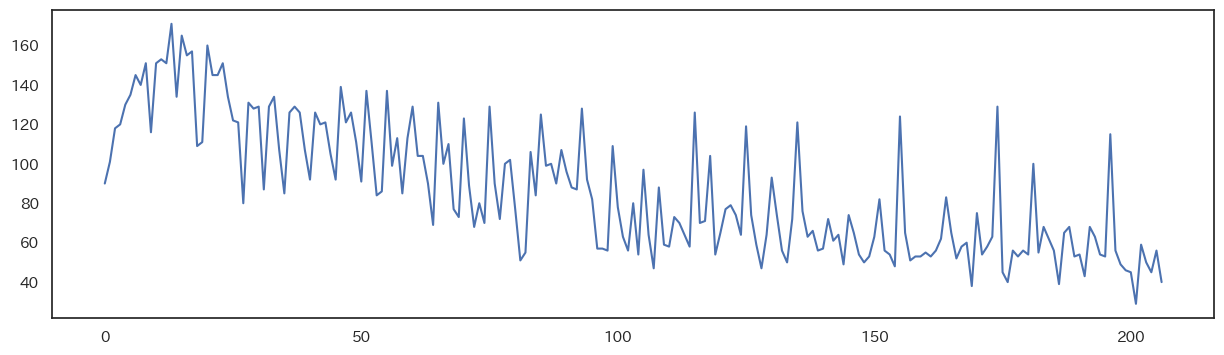

In [23]:
### 欠損値補完と月情報の特徴量の作成
import pandas as pd
import japanize_matplotlib


train = pd.read_csv('./data/01/train.csv')


print("kcalカラムの要約統計量:")
display(train['kcal'].describe()) # kcalカラムの要約統計量を

print('大きなばらつきがないため、kcalカラムは平均値で補完。')
train['kcal'] = train['kcal'].fillna(train['kcal'].mean()).astype(int) # 平均値で補完し、整数型に変換

# payday、precipitation、event、remarksの欠損値を補完
train['payday'] = train['payday'].fillna(0) # paydayの欠損値を0で補完
train["precipitation"] = train["precipitation"].apply(lambda x : -1 if x == "--" else float(x)) # precipitationの欠損値を-1で補完し、数値型に変換
train['event'] = train['event'].fillna('なし') # eventの欠損値を「なし」で補完
train['remarks'] = train['remarks'].fillna('なし') # remarksの欠損値を「なし」で補完

train["month"] = train["datetime"].apply(lambda x : int(x.split("-")[1])) # datetimeから月を抽出してmonthカラムを作成


print("\n補完後の欠損値の数:")
display(train.isnull().sum()) # 補完後の欠損値の数を表示
display(train.head())

# csvファイルに保存
train.to_csv('./data/01/train_filled.csv', index=False)

# データの可視化
print("売上数の時系列プロット:")
display(train["y"].plot(figsize=(15,4))) # 売上数の時系列プロットを表示



>- 日数が経過するにつれて売り上げが落ちて行っている
>- 落ちて行っているのにも関わらず、スパイクしている為、売り上げ数に寄与している何かしらの要因がある？

### 目的変数と説明変数(数値)との散布図の確認

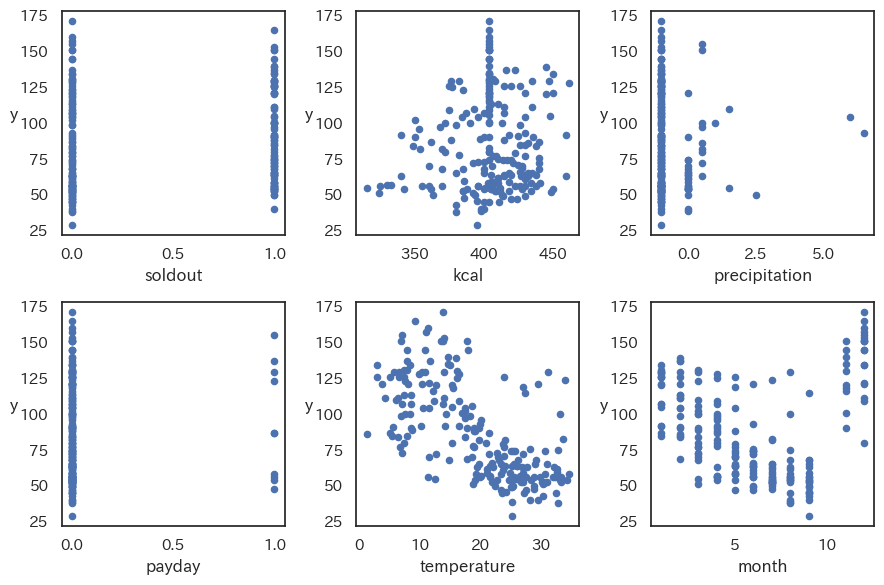

In [29]:
### 目的変数と説明変数(数値)との散布図の確認
import pandas as pd
import japanize_matplotlib
import matplotlib.pyplot as plt

train = pd.read_csv('./data/01/train_filled.csv') # 補完後のデータを読み込む

fig, ax = plt.subplots(2, 3, figsize=(9, 6))
train.plot.scatter(x="soldout", y="y", ax=ax[0][0])
train.plot.scatter(x="kcal", y="y", ax=ax[0][1])
train.plot.scatter(x="precipitation", y="y", ax=ax[0][2])
train.plot.scatter(x="payday", y="y", ax=ax[1][0])
train.plot.scatter(x="temperature", y="y", ax=ax[1][1])
train.plot.scatter(x="month", y="y", ax=ax[1][2])

for a in ax.ravel():
    a.set_ylabel("y", rotation=0)

plt.tight_layout()

>月及び気温は売上数と相関が高そうだが、日数が経過するにつれて減衰している性質がある為、代替変数である可能性が高い
>
>__代替変数__
>- 「本来は別の『真の原因』があるが、その原因を直接データとして取れないため、身代わりに使っている変数」のこと
>- 「気温が上がったから売上が落ちた」のではなく、「ただ時間が経って飽きられただけ」という可能性がある。

### 目的変数と説明変数(カテゴリカルデータ)との箱ひげ図の確認

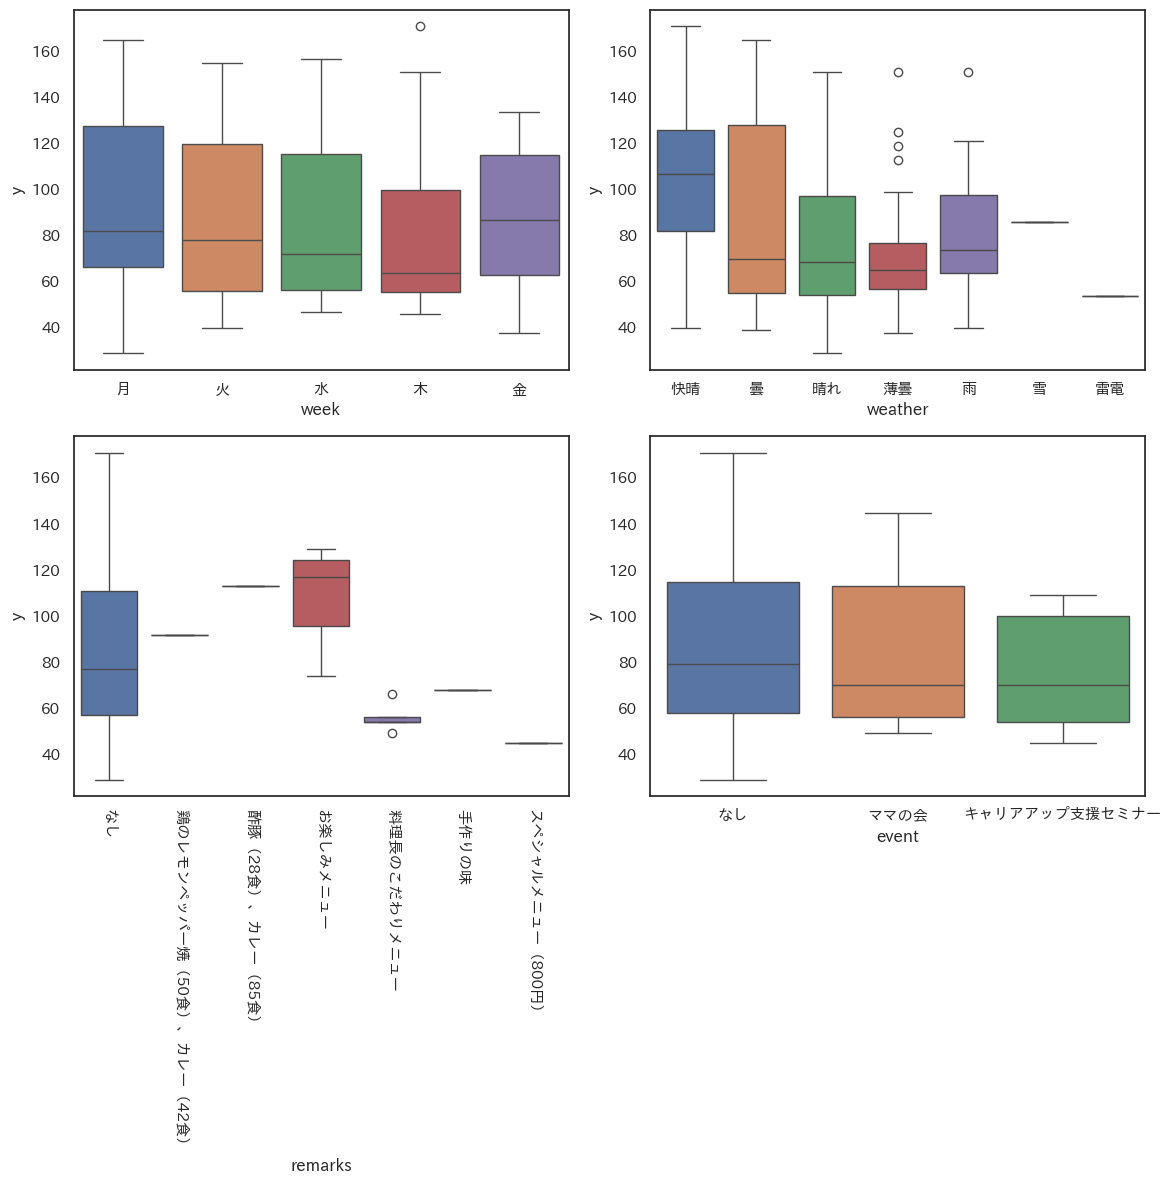

In [44]:
### 目的変数と説明変数(カテゴリー)との箱ひげ図の確認
import pandas as pd
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('./data/01/train_filled.csv') # 補完後のデータを読み込む

fig, ax = plt.subplots(2,2,figsize=(12,12))
sns.boxplot(x="week",y="y",hue='week' ,data=train,ax=ax[0][0])
sns.boxplot(x="weather",y="y",hue='weather',data=train,ax=ax[0][1])
sns.boxplot(x="remarks",y="y",hue='remarks',data=train,ax=ax[1][0])
ax[1][0].tick_params(axis='x', rotation=-90) # x軸のラベルを90度回転させて、重ならないようにする
sns.boxplot(x="event",y="y",hue='event',data=train,ax=ax[1][1])
plt.tight_layout() # グラフ同士のレイアウトを調整して、重ならないようにする

>お楽しみメニューの有無により、売上数に有意な差を確認（なしの場合と比較して顕著に反応）

### 売り上げ数のプロットを比較

<Axes: xlabel='datetime', ylabel='y'>

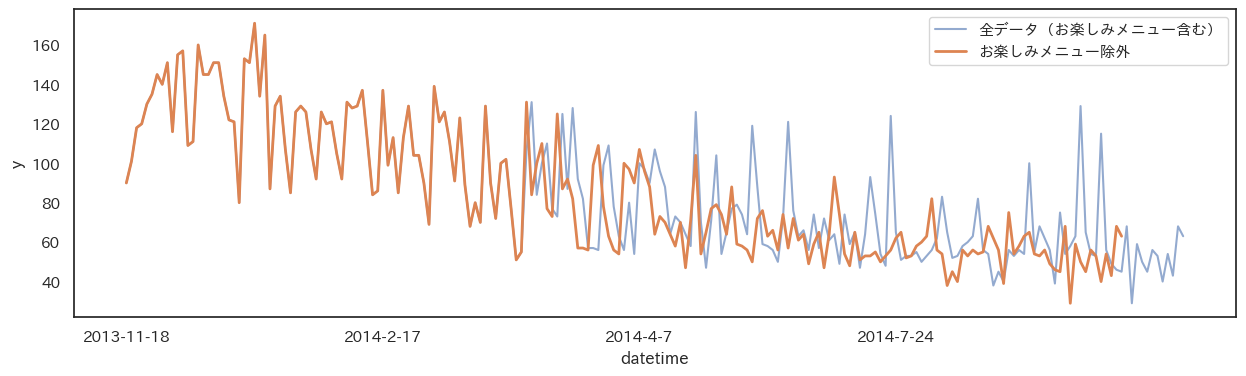

In [ ]:
### 目的変数と説明変数(カテゴリー)との箱ひげ図の確認
import pandas as pd
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('./data/01/train_filled.csv') # 補完後のデータを読み込む


# 「お楽しみメニューを含む場合」と「除いた場合」を重ねて表示
plot_df = train.copy() # データフレームをコピーして、元のデータを変更しないようにする
plot_df = plot_df.sort_values("datetime") # datetimeでソートして、時系列順にプロットできるようにする

# 「お楽しみメニューを含む場合」のプロット
ax = plot_df.plot(
    x="datetime", y="y", figsize=(15, 4),
    label="全データ（お楽しみメニュー含む）", alpha=0.6
)

# 「お楽しみメニューを除いた場合」のプロット
plot_df[plot_df["remarks"] != "お楽しみメニュー"].plot(
    x="datetime", y="y", ax=ax,
    label="お楽しみメニュー除外", linewidth=2
)

ax.set_xlabel("datetime")
ax.set_ylabel("y")
ax.legend()
display(ax)



>お楽しみメニューを除いた場合に、後半の売り上げ数のスパイクが減少
>
> --> スパイクの原因はお楽しみメニューであるかもしれない

### 中央値検定
2つのグループの中央値が統計的に有意に異なるかどうかを検定する方法

<Axes: xlabel='is_fun', ylabel='y'>

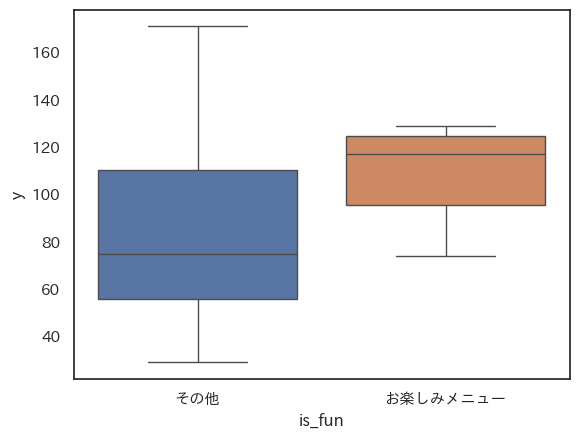

In [61]:
### 中央値検定
# 目的変数yの中央値が「お楽しみメニューを含む場合」と「除いた場合」で異なるかどうかを検定。
import pandas as pd
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('./data/01/train_filled.csv') # 補完後のデータを読み込む


train["is_fun"] = train["remarks"].apply(lambda x: 'お楽しみメニュー' if x=="お楽しみメニュー" else 'その他')
sns.boxplot(x="is_fun",y="y",hue="is_fun",data=train)


>お楽しみメニューがあるかないかで比較しても、中央値検定によれば有意に差があることが分かる

### メディアン検定

2つの独立したサンプルの中央値が等しいかどうかを検定する非パラメトリックな方法

>パラメトリックと非パラメトリック
>- パラメトリック
>   - データが正規分布に従うと仮定して行う検定方法。
>- ノンパラメトリック(非パラメトリック)
>   - データが正規分布に従うと仮定せずに行う検定方法。

In [ ]:
### メディアン検定
# 目的変数yの中央値が「お楽しみメニューを含む場合」と「除いた場合」で異なるかどうかを検定。
import pandas as pd
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_test # メディアン検定を行うための関数をインポート

train = pd.read_csv('./data/01/train_filled.csv') # 補完後のデータを読み込む

# 「お楽しみメニューを含む場合」と「除いた場合」を判別するカラムを作成
train["is_fun"] = train["remarks"].apply(lambda x: 'お楽しみメニュー' if x=="お楽しみメニュー" else 'その他')

# メディアン検定を実行
stat,p,med,tbl = median_test(train[train["is_fun"]=='お楽しみメニュー']["y"],train[train["is_fun"]=='その他']["y"])
print("p",p,"stat",stat)

if p < 0.05:
    print("中央値が有意に異なると判断")
else:
    print("中央値に有意な差はないと判断")

p 0.007057960766247775 stat 7.2581589841730345
中央値が有意に異なると判断


>p値が0.05より小さいため、「お楽しみメニューを含む場合」と「除いた場合」で目的変数yの中央値は有意に異なるといえる。

### 売り上げ詳細

<Axes: >

,datetime,y,week,soldout,name,kcal,remarks,event,payday,weather,precipitation,temperature,month
83,2014-3-28,106,金,0,キーマカレー,404,お楽しみメニュー,なし,0.0,快晴,-1.0,18.5,3
93,2014-4-11,128,金,1,チキンカレー,404,お楽しみメニュー,なし,0.0,快晴,-1.0,16.5,4
103,2014-4-25,80,金,0,中華丼,404,お楽しみメニュー,なし,0.0,晴れ,-1.0,20.8,4
115,2014-5-16,126,金,0,ポークカレー,404,お楽しみメニュー,ママの会,0.0,快晴,-1.0,23.8,5
125,2014-5-30,119,金,0,チキンカレー,404,お楽しみメニュー,なし,0.0,薄曇,-1.0,26.9,5
135,2014-6-13,121,金,0,キーマカレー,404,お楽しみメニュー,なし,0.0,晴れ,-1.0,29.5,6
145,2014-6-27,74,金,0,牛丼,404,お楽しみメニュー,なし,0.0,雨,0.0,25.4,6
155,2014-7-11,124,金,0,ポークカレー,404,お楽しみメニュー,なし,0.0,晴れ,-1.0,33.9,7
164,2014-7-25,83,金,0,ひやしたぬきうどん・炊き込みご飯,404,お楽しみメニュー,なし,0.0,晴れ,-1.0,33.6,7
174,2014-8-8,129,金,0,チキンカレー,404,お楽しみメニュー,なし,1.0,曇,-1.0,31.1,8


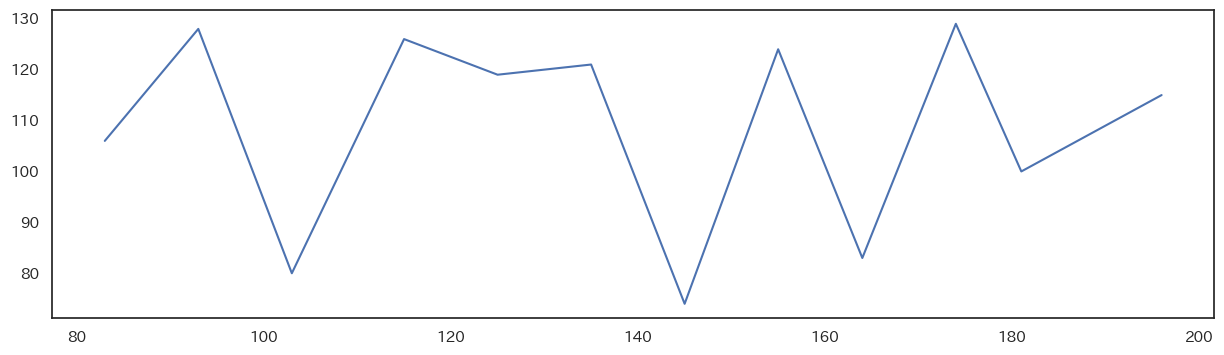

In [73]:
### お楽しみメニュー時の売り上げを確認
import pandas as pd


train = pd.read_csv('./data/01/train_filled.csv') # 補完後のデータを読み込む

display(train[train["remarks"]=="お楽しみメニュー"]["y"].plot(figsize=(15,4)))

display(train[train["remarks"]=="お楽しみメニュー"])

>お楽しみメニューの中でも、売り上げに凹凸が見られる
>- カレーか否かが重要そう

<Axes: xlabel='curry', ylabel='y'>

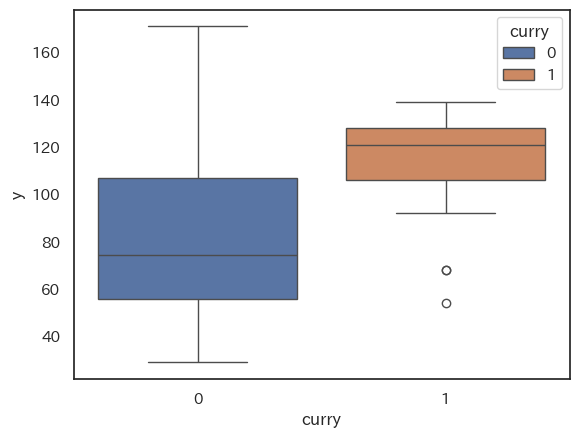

In [78]:
### カレーかどうかで売り上げを確認
import pandas as pd
import seaborn as sns


train = pd.read_csv('./data/01/train_filled.csv') # 補完後のデータを読み込む

train["curry"] = train["name"].apply(lambda x : 1 if x.find("カレー")>=0 else 0)
sns.boxplot(x="curry",y="y",hue="curry",data=train)

In [79]:
### メディアン検定
# 目的変数yの中央値が「カレー」と「カレー以外」で異なるかどうかを検定。
import pandas as pd
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_test # メディアン検定を行うための関数をインポート

train = pd.read_csv('./data/01/train_filled.csv') # 補完後のデータを読み込む

# 「カレー」と「カレー以外」を判別するカラムを作成
train["curry"] = train["name"].apply(lambda x : 1 if x.find("カレー")>=0 else 0)
# メディアン検定を実行
stat,p,med,tbl = median_test(train[train["curry"]==1]["y"],train[train["curry"]==0]["y"])
print("p",p,"stat",stat)

if p < 0.05:
    print("中央値が有意に異なると判断")
else:
    print("中央値に有意な差はないと判断")

p 0.010699742900892427 stat 6.514516162828877
中央値が有意に異なると判断


>p値が0.05より小さいため、「カレー」と「カレー以外」で目的変数yの中央値は有意に異なるといえる。

### Method
- 日数が経過するにつれて減衰している為、売上数と日数の単回帰モデルを軸に検討する
    - 但し、2014-05以前はやや傾向が異なる為、学習データから除く
- 他、お楽しみメニューやカレー等は大きく寄与はしていそうだが、非線形な関係であることも考慮し、Random Forestを用いて単回帰モデルの結果を修正するモデルも作成し、予測結果を導出する

TRAIN(RMSE): 7.567045890582926 VALIDATE(RMSE): 12.108512732864117
TRAIN(RMSE): 7.898879809389376 VALIDATE(RMSE): 10.596024908707413
TRAIN(RMSE): 8.257827724786777 VALIDATE(RMSE): 8.842687980106906
TRAIN(RMSE): 7.954599685874008 VALIDATE(RMSE): 19.93205551309561
TRAIN(RMSE): 7.913918883780418 VALIDATE(RMSE): 9.443466823946043

AVG(RMSE)
TRAIN: 7.918454398882702 VALIDATE: 12.184549591744016


<Axes: >


RMSE 7.986229908417227


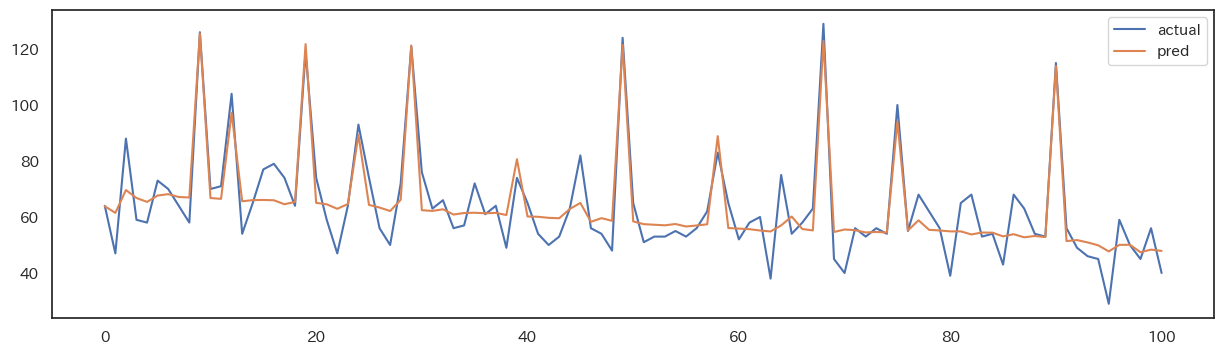

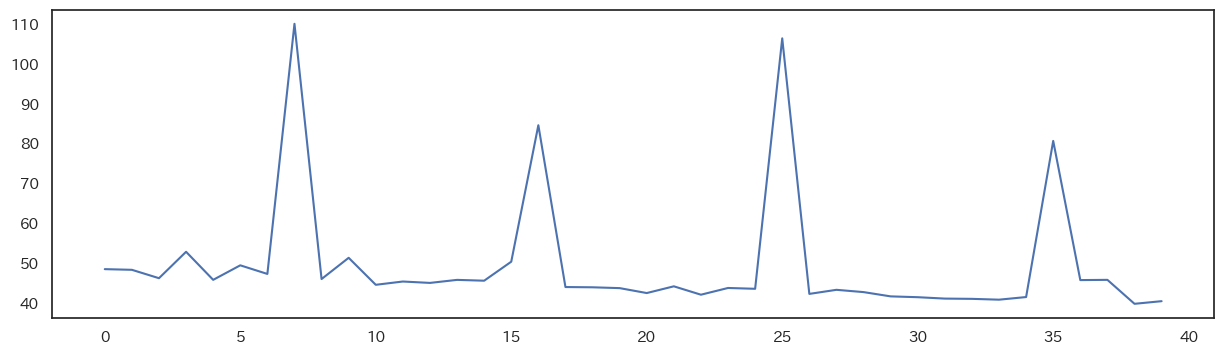

In [93]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error as MSE
from sklearn.linear_model import LinearRegression as LR
from sklearn.ensemble import RandomForestRegressor as RF


train = pd.read_csv("./data/01/train.csv")
test = pd.read_csv("./data/01/test.csv")
sample = pd.read_csv("./data/01/sample.csv",header=None)

train["t"] = 1
test["t"] = 0
dat = pd.concat([train,test],sort=True).reset_index(drop=True)

dat.index = pd.to_datetime(dat["datetime"])
dat = dat["2014-05-01":]
dat = dat.reset_index(drop=True)


dat["days"] = dat.index
dat["precipitation"] = dat["precipitation"].apply(lambda x : -1 if x=="--" else x).astype(float)
dat["fun"] = dat["remarks"].apply(lambda x: 1 if x=="お楽しみメニュー" else 0)
dat["curry"] = dat["name"].apply(lambda x : 1 if x.find("カレー")>=0 else 0)

cols = ["precipitation","weather","days","fun","curry","y"]

def learning(trainX,y_train):
    model1 = LR()
    model2 = RF(n_estimators=100,max_depth=4,random_state=777)
    model1.fit(trainX["days"].values.reshape(-1,1),y_train)
    pred = model1.predict(trainX["days"].values.reshape(-1,1))

    pred_sub = y_train - pred
    model2.fit(trainX.iloc[:, ~trainX.columns.str.match("y")],pred_sub)
    return model1, model2


# kf = KFold(n_splits=5,random_state=777)
kf = KFold(n_splits=5)
tr = dat[dat["t"]==1][cols]

trains = []
tests = []
for train_index, test_index in kf.split(tr):
    tr.loc[train_index,"tt"] = 1
    tr.loc[test_index,"tt"] = 0
    tr["tt"] = tr["tt"].astype(int)
    tmp = pd.get_dummies(tr)

    trainX = tmp[tmp["tt"]==1]
    del trainX["tt"]
    testX = tmp[tmp["tt"]==0]
    del testX["tt"]
    y_train = tmp[tmp["tt"]==1]["y"]
    y_test = tmp[tmp["tt"]==0]["y"]

    model1, model2 = learning(trainX, y_train)

    pred_train = model1.predict(trainX["days"].values.reshape(-1,1)) + model2.predict(trainX.iloc[:, ~trainX.columns.str.match("y")])
    pred_test = model1.predict(testX["days"].values.reshape(-1,1)) + model2.predict(testX.iloc[:, ~testX.columns.str.match("y")])

    print("TRAIN(RMSE):",MSE(y_train,pred_train)**0.5, "VALIDATE(RMSE):",MSE(y_test, pred_test)**0.5)
    trains.append(MSE(y_train,pred_train)**0.5)
    tests.append(MSE(y_test, pred_test)**0.5)
print("\nAVG(RMSE)")
print("TRAIN:",np.array(trains).mean(), "VALIDATE:", np.array(tests).mean()) 


cols = ["precipitation","weather","days","fun","curry","y","t"]
tmp = pd.get_dummies(dat[cols])
trainX = tmp[tmp["t"]==1]
del trainX["t"]
testX = tmp[tmp["t"]==0]
del testX["t"]
y_train = tmp[tmp["t"]==1]["y"]
y_test = tmp[tmp["t"]==0]["y"]

model1, model2 = learning(trainX,y_train)
pred = model1.predict(trainX["days"].values.reshape(-1,1)) + model2.predict(trainX.iloc[:,~trainX.columns.str.match("y")])


p = pd.DataFrame({"actual":y_train,"pred":pred})
display(p.plot(figsize=(15,4)))

# RMSEの表示
print("\nRMSE",MSE(y_train,pred)**0.5)


model1, model2 = learning(trainX,y_train)
pred = model1.predict(testX["days"].values.reshape(-1,1)) + model2.predict(testX.iloc[:,~testX.columns.str.match("y")])
plt.figure(figsize=(15,4))
plt.plot(pred)
plt.show()


sample[1] = pred
sample.to_csv("./data/01/submit01.csv",index=None,header=None)


### Conclution
- お弁当の需要予測を題材とし、基礎分析の結果から2種類のモデルを利用。
- 1つ目は日数が経過することに減少傾向だったため、日数と需要量との単回帰モデル。
- 2つ目は上記予測結果を更に細かく補正する為の非線形なモデルとしてRandomForestを採用。
    - スパイク要因に注目したところ、お楽しみメニューやカレーかどうかが重要であり、これらを表す特徴量を加えた結果、スパイクが予測できていた
- 課題として、小さな凸凹に対しては予測が不十分と考えられる為、これらに有効な特徴量を検討することが挙げられる。